# Study of Attention Mechanism

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
print(f'Import PyTorch V{torch.__version__}')

dev = torch.device(type='cuda') if torch.cuda.is_available() else torch.device(type='cpu')
print(f'Use device {dev}')

Import PyTorch V1.12.1
Use device cpu


In [2]:
from d2l import torch as d2l
d2l.use_svg_display()

## Queries, Keys, and Values

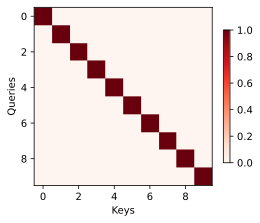

In [3]:
attention_weights = torch.eye(10).reshape(1, 1, 10, 10)
d2l.show_heatmaps(attention_weights, xlabel='Keys', ylabel='Queries', figsize=(4.0, 4.0))

## Attention Pooling by Similarity

In [4]:
# Define some kernels
def gaussian(x):
    return torch.exp(-x**2 / 2)

def boxcar(x):
    return torch.abs(x) < 1.0

def constant(x):
    return 1.0 + 0 * x

def epanechikov(x):
    return torch.max(1 - torch.abs(x), torch.zeros_like(x))

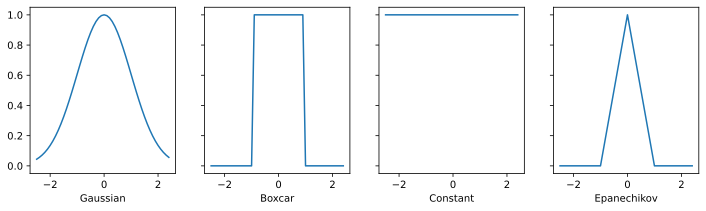

In [5]:
fig, axes = d2l.plt.subplots(1, 4, sharey=True, figsize=(12, 3))

kernels = (gaussian, boxcar, constant, epanechikov)
names = ('Gaussian', 'Boxcar', 'Constant', 'Epanechikov')
x = torch.arange(-2.5, 2.5, 0.1)

for kernel, name, ax in zip(kernels, names, axes):
    ax.plot(x.detach().numpy(), kernel(x).detach().numpy())
    ax.set_xlabel(name)

d2l.plt.show()

In [6]:
print('prepare training and validation data')

def f(x):
    """target function"""
    return 2 * torch.sin(x) + x

n = 50
xmax = 5.0
sigma = 1.0

x_train, _ = torch.sort(torch.rand(n) * xmax)
y_train = f(x_train) + torch.randn(n) * sigma

x_val = torch.arange(0.0, xmax, xmax / 100.0)
y_val = f(x_val)

prepare training and validation data


In [7]:
print('define Nadaraya-Watson regression')

def nadaraya_watson(x_train, y_train, x_val, kernel):
    distances = x_train.reshape((-1, 1)) - x_val.reshape((1, -1)) # generate distance matrix
    k = kernel(distances).type(torch.float32) # perform kernel
    attention_weights = k / k.sum(0) # normalization
    y_hat = y_train @ attention_weights # validation
    return y_hat, attention_weights


define Nadaraya-Watson regression


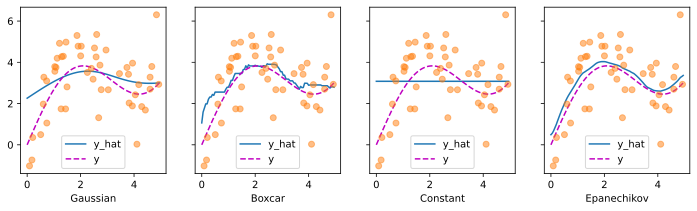

In [8]:
fig, axes = d2l.plt.subplots(1, len(kernels), sharey=True, figsize=(3 * len(kernels), 3))
for kernel, name, ax in zip(kernels, names, axes):
    y_hat, w = nadaraya_watson(x_train, y_train, x_val, kernel)
    ax.plot(x_val, y_hat)
    ax.plot(x_val, y_val, 'm--')
    ax.plot(x_train, y_train, 'o', alpha=0.5)
    ax.set_xlabel(name)
    ax.legend(['y_hat', 'y'])


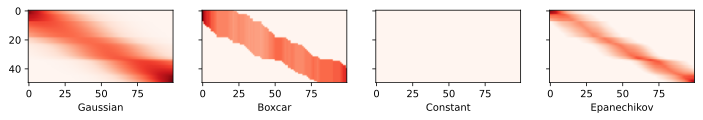

In [9]:
fig, axes = d2l.plt.subplots(1, len(kernels), sharey=True, figsize=(3 * len(kernels), 3))
for kernel, name, ax in zip(kernels, names, axes):
    y_hat, w = nadaraya_watson(x_train, y_train, x_val, kernel)
    pcm = ax.imshow(w.detach().numpy(), cmap='Reds')
    ax.set_xlabel(name)

## Attention Scoring Functions

In [10]:
d2l.masked_softmax(torch.rand(2, 2, 4), torch.tensor([2, 3]))

tensor([[[0.5090, 0.4910, 0.0000, 0.0000],
         [0.4601, 0.5399, 0.0000, 0.0000]],

        [[0.3208, 0.3369, 0.3423, 0.0000],
         [0.2690, 0.3841, 0.3469, 0.0000]]])

In [11]:
Q = torch.randn((2, 3, 4))
K = torch.randn((2, 4, 6))
torch.bmm(Q, K)

tensor([[[ 0.0276,  1.3239, -0.3007, -0.3522,  1.2432,  0.3544],
         [-2.5162, -0.7054, -0.6857,  0.0791, -1.0626, -0.3101],
         [ 0.8803, -0.9693, -1.4067, -0.2241, -0.7428, -0.4095]],

        [[ 0.4318,  1.7469,  0.8564,  0.4695, -0.1634,  0.6476],
         [-3.6381,  4.5755, -0.1818, -1.5940,  1.6020,  0.4143],
         [-0.1180, -1.1805, -1.7540,  0.0330,  1.3957,  0.9149]]])

Try out dot production attention

$$softmax(\frac{Q K^T}{\sqrt{d}})V \in R^{n \times v}$$

In [12]:
queries = torch.normal(0, 1, (2, 3, 2))
keys = torch.normal(0, 1, (2, 10, 2))
values = torch.normal(0, 1, (2, 10, 4))
valid_lens = torch.tensor([5, 7])

attention = d2l.DotProductAttention(dropout=0.5)

attention.eval()
attention(queries, keys, values, valid_lens)

tensor([[[ 0.6296,  0.1242,  0.2244, -1.5523],
         [ 0.2075,  0.4945, -0.1921, -1.0082],
         [-0.3454, -0.3436, -0.2078,  0.1784]],

        [[-0.0877,  0.6118, -0.1548,  0.1114],
         [ 0.0199,  0.5888, -0.0867,  0.1111],
         [ 0.0714,  0.5203,  0.0295,  0.0976]]])

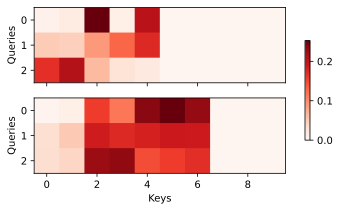

In [13]:
d2l.show_heatmaps(attention.attention_weights.reshape((2, 1, 3, 10)),
                  xlabel='Keys', ylabel='Queries', figsize=(7, 3))

Try out additive attention

$$\alpha(q, k) = softmax(a(q, k)) = softmax(\omega_v^T \tanh(W_q q + W_k k)) \in R$$

In [20]:
additive_attention = d2l.AdditiveAttention(num_hiddens=7, dropout=0.5)
additive_attention.eval()

/Users/hzhou/anaconda3/envs/pytorch/lib/python3.9/site-packages/torch/nn/modules/lazy.py:178: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


AdditiveAttention(
  (W_k): LazyLinear(in_features=0, out_features=7, bias=False)
  (W_q): LazyLinear(in_features=0, out_features=7, bias=False)
  (w_v): LazyLinear(in_features=0, out_features=1, bias=False)
  (dropout): Dropout(p=0.5, inplace=False)
)

In [22]:
additive_attention(queries, keys, values, valid_lens)

tensor([[[ 0.0996,  0.1691, -0.1692, -0.4607],
         [ 0.0690,  0.2174, -0.1965, -0.4842],
         [ 0.0878,  0.1469, -0.1747, -0.4607]],

        [[ 0.0861,  0.6767, -0.1697,  0.1722],
         [ 0.0852,  0.6864, -0.1700,  0.1692],
         [ 0.0927,  0.6747, -0.1761,  0.1702]]], grad_fn=<BmmBackward0>)

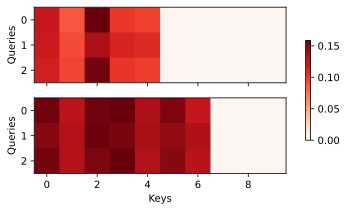

In [23]:
d2l.show_heatmaps(additive_attention.attention_weights.reshape((2, 1, 3, 10)),
                  xlabel='Keys', ylabel='Queries', figsize=(7, 3))